In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('data.csv')

In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


----Data Preparation part 1

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
str_col = list(df.dtypes[df.dtypes == 'str'].index)
for col in str_col:
    df[col] = df[col].str.lower().str.replace(' ', '_')

----EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

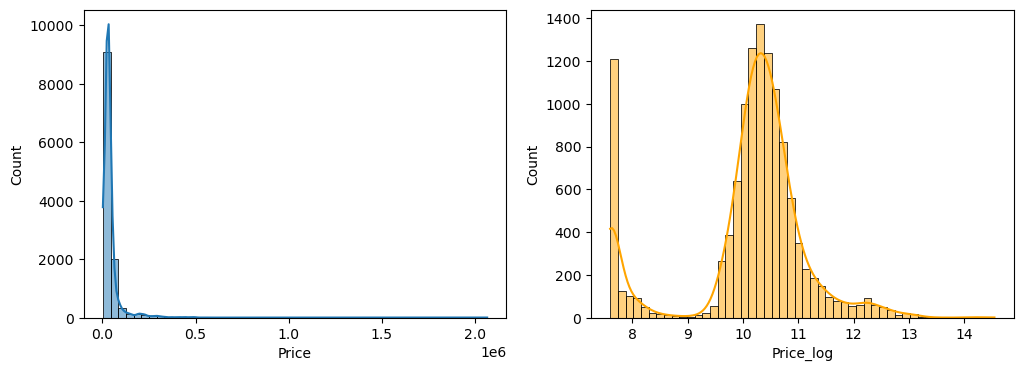

In [8]:
fig, ax = plt.subplots(1, 2, figsize= (12, 4))
sns.histplot(data= df.msrp, bins= 50, ax= ax[0], kde= True)
ax[0].set_xlabel('Price')
sns.histplot(data= np.log1p(df.msrp), bins= 50, ax= ax[1], color= 'orange', kde= True)
ax[1].set_xlabel('Price_log')
plt.show()

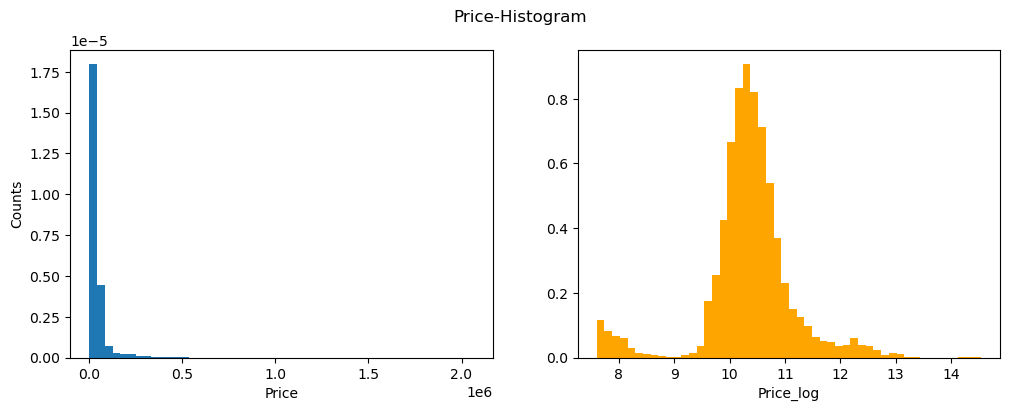

In [9]:
df = df[df['msrp'] != 2000].reset_index(drop= True)
fig, ax = plt.subplots(1, 2, figsize= (12, 4))
ax[0].hist(df.msrp, bins= 50, density= True)
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Counts')
ax[1].hist(np.log1p(df.msrp), bins= 50, color= 'orange', density= True)
ax[1].set_xlabel('Price_log')
fig.suptitle('Price-Histogram')
plt.show()

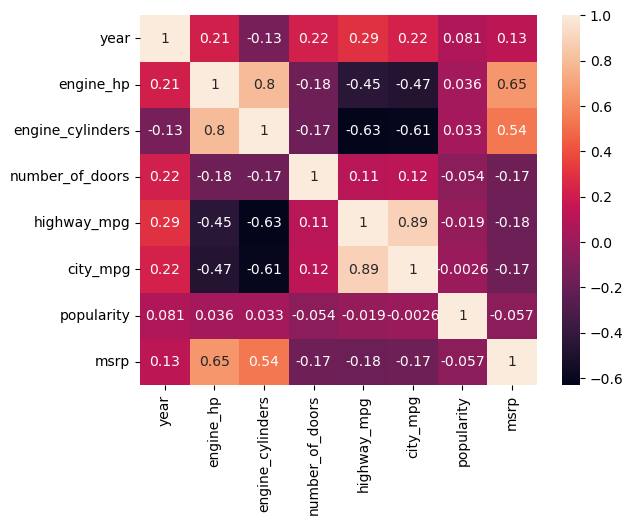

In [10]:
correl = df.corr(numeric_only= True)
sns.heatmap(correl, annot= True)
plt.show()

In [11]:
df['msrp_log'] = np.log1p(df['msrp'])

----Missing Values

In [12]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3067
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
msrp_log                0
dtype: int64

----Split The DataSet into Test, Validation and Train Set

In [13]:
n = len(df)

In [14]:
n_test = int(0.2 * n)
n_val = int(0.2 * n)

In [15]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx)

In [16]:
df_train = df.iloc[idx[n_val + n_test: ]].reset_index(drop= True)
df_test = df.iloc[idx[: n_test]].reset_index(drop= True)
df_val = df.iloc[idx[n_test: n_val + n_test]].reset_index(drop= True)

----Data Preparation part 2

In [17]:
y_train = df_train.iloc[:, -1].values
y_test = df_test.iloc[:, -1].values
y_val = df_val.iloc[:, -1].values

In [18]:
from utils import Standardisation, Dummies

In [19]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [20]:
std_factor = Standardisation()
X_train = std_factor.fit_transform(df_train[base].fillna(0).values)
X_test = std_factor.transform(df_test[base].fillna(0).values)
X_val = std_factor.transform(df_val[base].fillna(0).values)

----Training the Model - Linear Regression: Ordinary-Least-Squares(OLS) vs Gradient-Descent(GD)

In [21]:
from regressors import Regression_model

In [22]:
ols_model = Regression_model(method= 'ols')

In [23]:
w_ols = ols_model.train(X_train, y_train)

In [24]:
gd_model = Regression_model(learning_rate= 0.01, max_itter= 1000)

In [25]:
w_gd = gd_model.train(X_train, y_train)

100%|████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3356.32it/s]


In [26]:
w_ols, w_gd

(array([10.35297856,  0.72911819, -0.11615689,  0.11159139,  0.07951882,
        -0.04245769]),
 array([10.35253161,  0.67751909, -0.05332468,  0.12677362,  0.08185409,
        -0.04307492]))

----OLS vs GD Predictions on Training Set

In [27]:
ols_pred = ols_model.predict(X_train)
gd_pred = gd_model.predict(X_train)

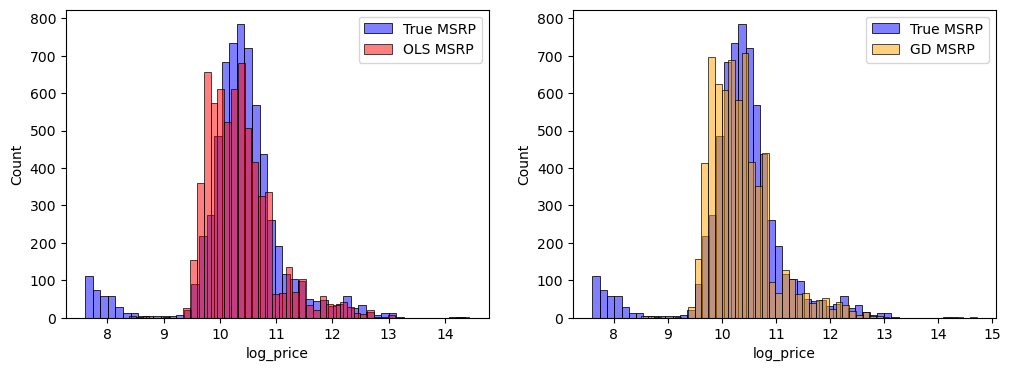

In [28]:
fig, ax = plt.subplots(1, 2, figsize= (12, 4))
sns.histplot(y_train, bins= 50, color= 'blue', alpha= 0.5, ax= ax[0], label= 'True MSRP')
sns.histplot(ols_pred, bins= 50, color= 'red', alpha= 0.5, ax= ax[0], label= 'OLS MSRP')
sns.histplot(y_train, bins= 50, color= 'blue', alpha= 0.5, ax= ax[1], label= 'True MSRP')
sns.histplot(gd_pred, bins= 50, color= 'orange', alpha= 0.5, ax= ax[1], label= 'GD MSRP')
ax[0].set_xlabel('log_price')
ax[1].set_xlabel('log_price')
ax[0].legend()
ax[1].legend()
plt.show()

----Model Valuation with Root Mean Squared Error

In [29]:
ols_error = ols_model.rmse(y_train, ols_pred)
gd_error = gd_model.rmse(y_train, gd_pred)

In [30]:
print(f'OLS ERROR: {ols_error:.4f}\nGD ERROR:  {gd_error:.4f}')

OLS ERROR: 0.5714
GD ERROR:  0.5725


----Train the Model on Train Set Vs Validation Set using OLS method

In [31]:
val_model = Regression_model(method= 'ols')
w_val = val_model.train(X_val, y_val)

In [32]:
w_val

array([10.34574676,  0.75111781, -0.10760809,  0.29541307, -0.0368911 ,
       -0.02703667])

In [33]:
val_pred = val_model.predict(X_val)
val_pred_train = ols_model.predict(X_val)

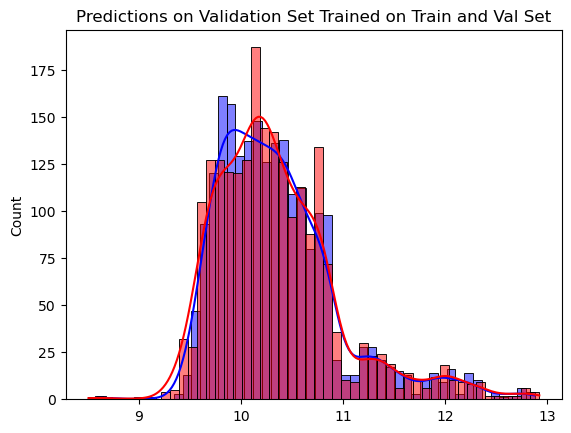

In [56]:
sns.histplot(val_pred_train, bins= 50, color= 'blue', alpha= 0.5, kde= True)
sns.histplot(val_pred, bins= 50, color= 'red', alpha= 0.5, kde= True)
plt.title('Predictions on Validation Set Trained on Train and Val Set')
plt.show()

In [35]:
print(f'RMSE of Val Predictions trained on Val Set is:{val_model.rmse(y_val, val_pred):.4f}\nRMSE of Val Predictions' + 
      f' trained on Train Set is:{ols_model.rmse(y_val, val_pred_train):.4f}')

RMSE of Val Predictions trained on Val Set is:0.5543
RMSE of Val Predictions trained on Train Set is:0.5578


----Add more Features (basic Data Engineering) and training the model on train Set valuating on validation Set

In [36]:
df_train['age'] = df_train['year'].max() - df_train['year']
df_val['age'] = df_val['year'].max() - df_val['year']
df_test['age'] = df_test['year'].max() - df_test['year']

In [37]:
model_ols_plus = Regression_model(method= 'ols')
std_plus = Standardisation()
X_train_plus = std_plus.fit_transform(df_train[base + ['age']].fillna(0).values)

In [38]:
w_ols_plus = model_ols_plus.train(X_train_plus, y_train)

In [39]:
X_val_plus = std_plus.transform(df_val[base + ['age']].fillna(0).values)
val_pred_plus = model_ols_plus.predict(X_val_plus)

In [40]:
ols_plus_error = model_ols_plus.rmse(val_pred_plus, y_val)

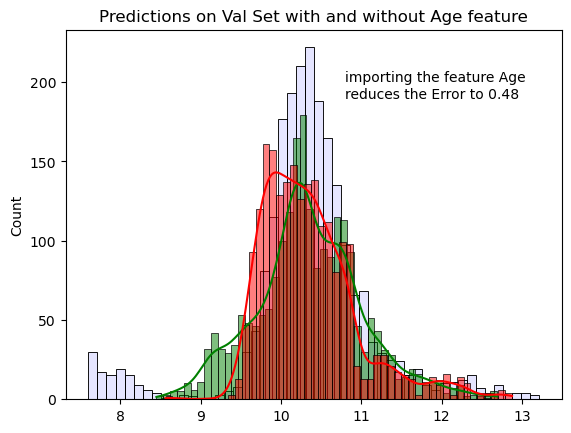

In [41]:
sns.histplot(y_val, bins= 50, color= 'blue', alpha= 0.1)
sns.histplot(val_pred_plus, bins= 50, color= 'green', alpha= 0.5, kde= True)
sns.histplot(val_pred_train, bins= 50, color= 'red', alpha= 0.5, kde= True)
plt.title('Predictions on Val Set with and without Age feature')
plt.text(10.8, 190, f'importing the feature Age\nreduces the Error to {ols_plus_error:.2f}')
plt.show()

----Import Dummies variables into the model

In [42]:
pseudo_var = Dummies()
pseudo_var.fit(df_train, columns= ['engine_fuel_type', 'transmission_type'])

In [43]:
X_train_d = np.column_stack([X_train_plus, pseudo_var.transform(df_train, form= 'matrix')])
X_val_d = np.column_stack([X_val_plus, pseudo_var.transform(df_val, form= 'matrix')])
model_d = Regression_model(method= 'ols', reg_lambda= 0.0001)

In [44]:
w_dumm = model_d.train(X_train_d, y_train)
w_dumm

array([ 9.43805231e+00,  2.09497032e-01,  1.62382030e-01, -7.86017143e-03,
       -5.70363637e-02, -5.17696937e-02, -4.09431537e-01,  2.42716477e-01,
       -3.12388104e-01, -1.42889264e-01, -4.06379960e-01,  2.80380381e-01,
        1.24255205e+00,  5.85484747e-02,  1.41239176e-01,  0.00000000e+00,
       -7.54005473e-02,  1.20712495e+00,  1.12265301e+00,  9.38682897e-01,
        1.22689331e+00])

In [45]:
val_d_pred = model_d.predict(X_val_d)

In [46]:
print(f'The Error after importing the Dummies is:{model_d.rmse(val_d_pred, y_val):.2f}')

The Error after importing the Dummies is:0.43


----Tuning the Hyperparameters

In [47]:
reg_factor = [1 / 10 ** i for i in range(9)]
rmse_list = []
for reg in reg_factor:
    model_tun = Regression_model(method= 'ols', reg_lambda= reg)
    model_tun.train(X_train_d, y_train)
    y_predict = model_tun.predict(X_val_d)
    rmse = model_tun.rmse(y_val, y_predict)
    rmse_list.append(rmse)

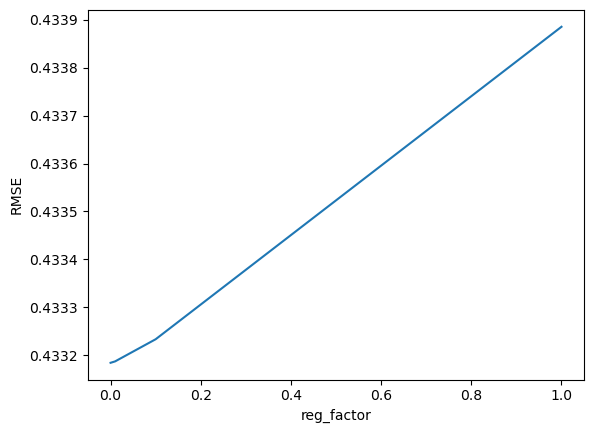

In [48]:
plt.plot(reg_factor, rmse_list)
plt.xlabel('reg_factor')
plt.ylabel('RMSE')
plt.show()

----Make Predictions with the final model

In [49]:
X_full_train = np.vstack([X_train_d, X_val_d])
y_full_train = np.hstack([y_train, y_val])

In [50]:
final_model = Regression_model(method= 'ols', reg_lambda= 0.000001)

In [51]:
final_model.train(X_full_train, y_full_train)

array([ 9.44185864,  0.21909618,  0.15259587, -0.01373096, -0.05275496,
       -0.04758179, -0.40423986,  0.18055858, -0.36747188, -0.19682377,
       -0.46229273,  0.22423364,  1.2312386 ,  0.02057477,  0.08183936,
        0.        , -0.07470975,  1.26722787,  1.17409903,  0.9860469 ,
        1.27783792])

In [52]:
X_test_plus = std_plus.transform(df_test[base + ['age']].fillna(0).values)

In [53]:
X_test_d = np.column_stack([X_test_plus, pseudo_var.transform(df_test, form= 'matrix')])

In [54]:
y_test_predict = final_model.predict(X_test_d)

In [55]:
print(f'The Error of predictions on Test set using for training the full Training set is: {final_model.rmse(y_test, y_test_predict):.2f}')

The Error of predictions on Test set using for training the full Training set is: 0.44
